In [16]:
import polars as pl
from tcrtrifold.tcrdock_utils import (
    dgeom_ndarr_from_dgeom_series,
    mn_distr_from_dgeom_ndarr,
    mn_distance_from,
    un_cossin_embed,
)
from tcrtrifold.utils import filter_to_cog_thresh, FORMAT_ANTIGEN_COLS, FORMAT_TCR_COLS


iedb_II_conf = pl.read_parquet(
    "../../data/iedb_II/triad/iedb_II_triad.conf_af3.parquet"
)
iedb_II_tcrdock = pl.read_parquet(
    "../../data/iedb_II/triad/staged/iedb_II_triad.af3_tcrdock.parquet"
)

iedb_II = iedb_II_conf.join(
    iedb_II_tcrdock.select("pred_dgeom_4", "job_name").with_columns(
        pl.col("pred_dgeom_4").struct.unnest()
    ),
    on="job_name",
    how="inner",
)

template_dgeom = pl.read_csv(
    "../../data/pdb/raw/ternary_templates_v2.tsv", separator="\t"
).with_columns(
    pl.struct(
        **{
            k: pl.col(k)
            for k in [
                "d",
                "torsion",
                "mhc_unit_x_is_negative",
                "tcr_unit_y",
                "tcr_unit_z",
                "tcr_unit_x_is_negative",
                "mhc_unit_y",
                "mhc_unit_z",
            ]
        }
    ).alias("dgeom"),
    pl.when(pl.col("mhc_class") == 1)
    .then(pl.lit("I"))
    .otherwise(pl.lit("II"))
    .alias("mhc_class"),
)

class_II_t_dgeom = dgeom_ndarr_from_dgeom_series(
    template_dgeom.filter(pl.col("mhc_class") == "II").select("dgeom").to_series()
)

class_II_distr = mn_distr_from_dgeom_ndarr(class_II_t_dgeom)

_, iedb_II_p_dgeom = mn_distance_from(
    dgeom_ndarr_from_dgeom_series(iedb_II.select("pred_dgeom_4").to_series()),
    *class_II_distr,
)

iedb_II = iedb_II.with_columns(pl.Series(name="p_dgeom", values=iedb_II_p_dgeom))

iedb_II = iedb_II.explode("references")

assay_type = pl.read_parquet("../../data/iedb_meta/assay_type.parquet")

iedb_II_best_pos = (
    iedb_II.explode("receptor_id")
    .join(assay_type, on="receptor_id")
    .filter(
        pl.col("assay_type").is_in(
            ["x-ray crystallography", "surface plasmon resonance (SPR)"]
        )
    )
    .select(pl.exclude("receptor_id", "assay_type"))
    .unique()
)

iedb_II_neg = (
    iedb_II.filter(~pl.col("cognate"))
    .join(iedb_II_best_pos.select(FORMAT_ANTIGEN_COLS).unique(), on=FORMAT_ANTIGEN_COLS)
    .select(pl.exclude("receptor_id"))
)

iedb_II_best = pl.concat([iedb_II_best_pos, iedb_II_neg])


cresta_conf = pl.read_parquet("../../data/cresta/triad/cresta_triad.conf_af3.parquet")
cresta_tcrdock = pl.read_parquet(
    "../../data/cresta/triad/staged/cresta_triad.af3_tcrdock.parquet"
)
cresta = cresta_conf.join(
    cresta_tcrdock.select("pred_dgeom_4", "job_name").with_columns(
        pl.col("pred_dgeom_4").struct.unnest()
    ),
    on="job_name",
    how="inner",
)

_, cresta_p_dgeom = mn_distance_from(
    dgeom_ndarr_from_dgeom_series(cresta.select("pred_dgeom_4").to_series()),
    *class_II_distr,
)

cresta = cresta.with_columns(pl.Series(name="p_dgeom", values=cresta_p_dgeom))

# Baseline


<Axes: xlabel='False Positive Rate', ylabel='True Positive Rate'>

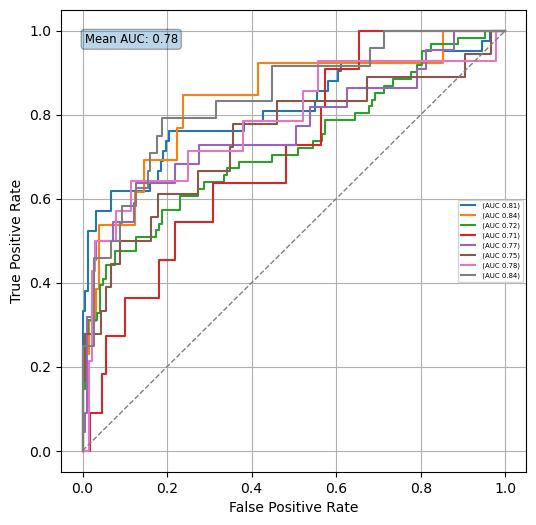

In [ ]:
from tcrtrifold.eval_utils import train_model, test_model, antigen_raw_score_auc
from tcrtrifold.viz_utils import plot_auc_per_antigen
import sklearn

cresta_auc_base = antigen_raw_score_auc(
    cresta.with_columns((31 - pl.col("mean_p_tcr_pae")).alias("mean_p_tcr_pae")),
    "mean_p_tcr_pae",
)

plot_auc_per_antigen(cresta_auc_base)

<Axes: xlabel='False Positive Rate', ylabel='True Positive Rate'>

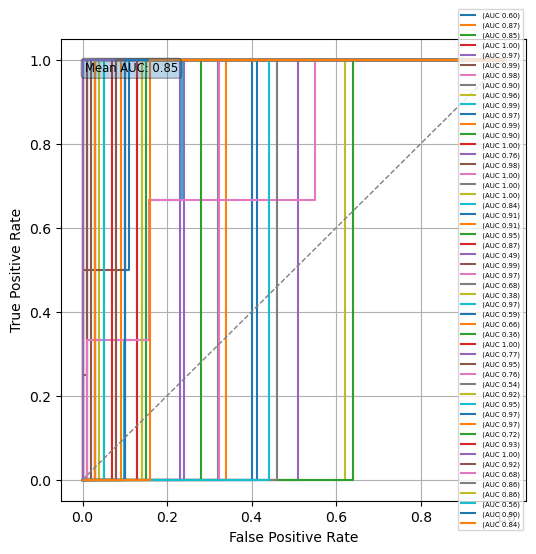

In [ ]:
iedb_II_auc_base = antigen_raw_score_auc(
    iedb_II_best.with_columns((31 - pl.col("mean_p_tcr_pae")).alias("mean_p_tcr_pae")),
    "mean_p_tcr_pae",
)

plot_auc_per_antigen(iedb_II_auc_base)

## IEDB -> CRESTA


In [111]:
featnames = [
    "mean_p_tcr_pae",
]

model = train_model(
    iedb_II_best,
    featnames,
    sklearn.linear_model.LogisticRegression,
)

_, _, _, auc = test_model(model, featnames, cresta)
print(auc)

0.7507150234368793


In [112]:
featnames = [
    "d",
    "mhc_unit_y",
    "mhc_unit_z",
    "tcr_unit_y",
    "tcr_unit_z",
    "torsion",
    "mean_p_tcr_pae",
    "mean_p_tcr_contact_prob",
    "tcr_mhc_contacts",
    "tcr_p_contacts",
]

model = train_model(
    iedb_II_best,
    featnames,
    sklearn.linear_model.LogisticRegression,
)

_, _, _, auc = test_model(model, featnames, cresta)
print(auc)

0.7157861285453245


In [31]:
import xgboost as xgb

featnames = [
    "d",
    "mhc_unit_y",
    "mhc_unit_z",
    "tcr_unit_y",
    "tcr_unit_z",
    "torsion",
    "mean_p_tcr_pae",
    "mean_p_tcr_contact_prob",
    "tcr_mhc_contacts",
    "tcr_p_contacts",
]

model = train_model(
    iedb_II_best,
    featnames,
    xgb.XGBClassifier,
    tree_method="exact",
)

_, _, _, auc = test_model(model, featnames, cresta)
print(auc)

0.6360371812187178


In [54]:
import xgboost as xgb

featnames = [
    "d",
    "mhc_unit_y",
    "mhc_unit_z",
    "tcr_unit_y",
    "tcr_unit_z",
    "torsion",
    "mean_p_tcr_pae",
    "mean_p_tcr_contact_prob",
    "tcr_mhc_contacts",
    "tcr_p_contacts",
]

model = train_model(
    iedb_II_best,
    featnames,
    sklearn.neural_network.MLPClassifier,
    hidden_layer_sizes=(5,),
    max_iter=500,
    early_stopping=True,
)

_, _, _, auc = test_model(model, featnames, cresta)
print(auc)

0.7578652578056726


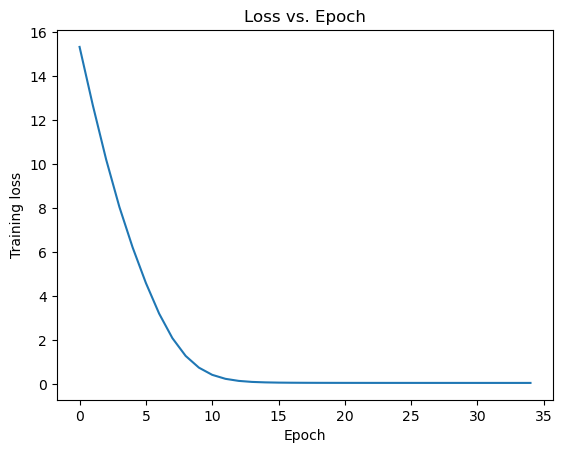

In [55]:
import matplotlib.pyplot as plt

plt.plot(model.loss_curve_)
plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.title("Loss vs. Epoch")
plt.show()

## CRESTA -> IEDB


In [120]:
featnames = [
    "mean_p_tcr_pae",
]

model = train_model(
    cresta,
    featnames,
    sklearn.linear_model.LogisticRegression,
)

_, _, _, auc = test_model(model, featnames, iedb_II_best)
print(auc)

0.7440906068734667


In [116]:
featnames = [
    # "d",
    "mhc_unit_y",
    "mhc_unit_z",
    "tcr_unit_y",
    "tcr_unit_z",
    "torsion",
    "mean_p_tcr_pae",
    "mean_p_tcr_contact_prob",
    "tcr_mhc_contacts",
    "tcr_p_contacts",
]

model = train_model(
    cresta,
    featnames,
    sklearn.linear_model.LogisticRegression,
)

_, _, _, auc = test_model(model, featnames, iedb_II_best)
print(auc)

0.7941198385950432


In [80]:
import xgboost as xgb

featnames = [
    "d",
    "mhc_unit_y",
    "mhc_unit_z",
    "tcr_unit_y",
    "tcr_unit_z",
    "torsion",
    "mean_p_tcr_pae",
    "mean_p_tcr_contact_prob",
    "tcr_mhc_contacts",
    "tcr_p_contacts",
]

model = train_model(
    cresta,
    featnames,
    xgb.XGBClassifier,
    tree_method="exact",
)

_, _, _, auc = test_model(model, featnames, iedb_II_best)
print(auc)

0.7124028475135843


In [83]:
import xgboost as xgb

featnames = [
    "d",
    "mhc_unit_y",
    "mhc_unit_z",
    "tcr_unit_y",
    "tcr_unit_z",
    "torsion",
    "mean_p_tcr_pae",
    "mean_p_tcr_contact_prob",
    "tcr_mhc_contacts",
    "tcr_p_contacts",
]

model = train_model(
    cresta,
    featnames,
    sklearn.neural_network.MLPClassifier,
    hidden_layer_sizes=(5,),
    max_iter=500,
    early_stopping=True,
)

_, _, _, auc = test_model(model, featnames, iedb_II_best)
print(auc)

0.7984472797303803


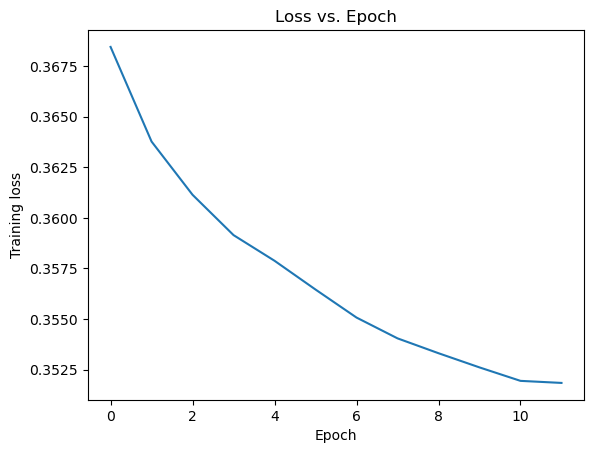

In [84]:
import matplotlib.pyplot as plt

plt.plot(model.loss_curve_)
plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.title("Loss vs. Epoch")
plt.show()